# Ingestão de Notas Fiscais

O workflow recebe o caminho de uma imagem, transcreve o texto com um modelo multimodal, extrai os campos em um esquema e confere o resultado por regras em código. A topologia é uma corrente de três nós, escrita no grafo e não decidida pelo modelo. Os vinte talões em `documents` vêm do conjunto `Francisco-Cruz/InvoicesReceiptsPT`, e os registros extraídos terminam em um banco SQLite.

In [1]:
# No Google Colab, descomente e rode uma vez.

# !pip install -q langchain langchain-openai langgraph

# import os
# from google.colab import userdata

# os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [2]:
import base64
import json
import sqlite3
from datetime import date
from pathlib import Path

import pandas as pd
from IPython.display import Image
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph

In [3]:
model = init_chat_model("openai:gpt-4.1-mini", temperature=0.0)

DOCUMENTS = sorted(Path("documents").glob("*.jpg"))
len(DOCUMENTS)

20

### O documento

Fotos de celular, tortas e com sombra, reduzidas para 1400 pixels no lado maior para cortar custo de imagem sem prejudicar a leitura.

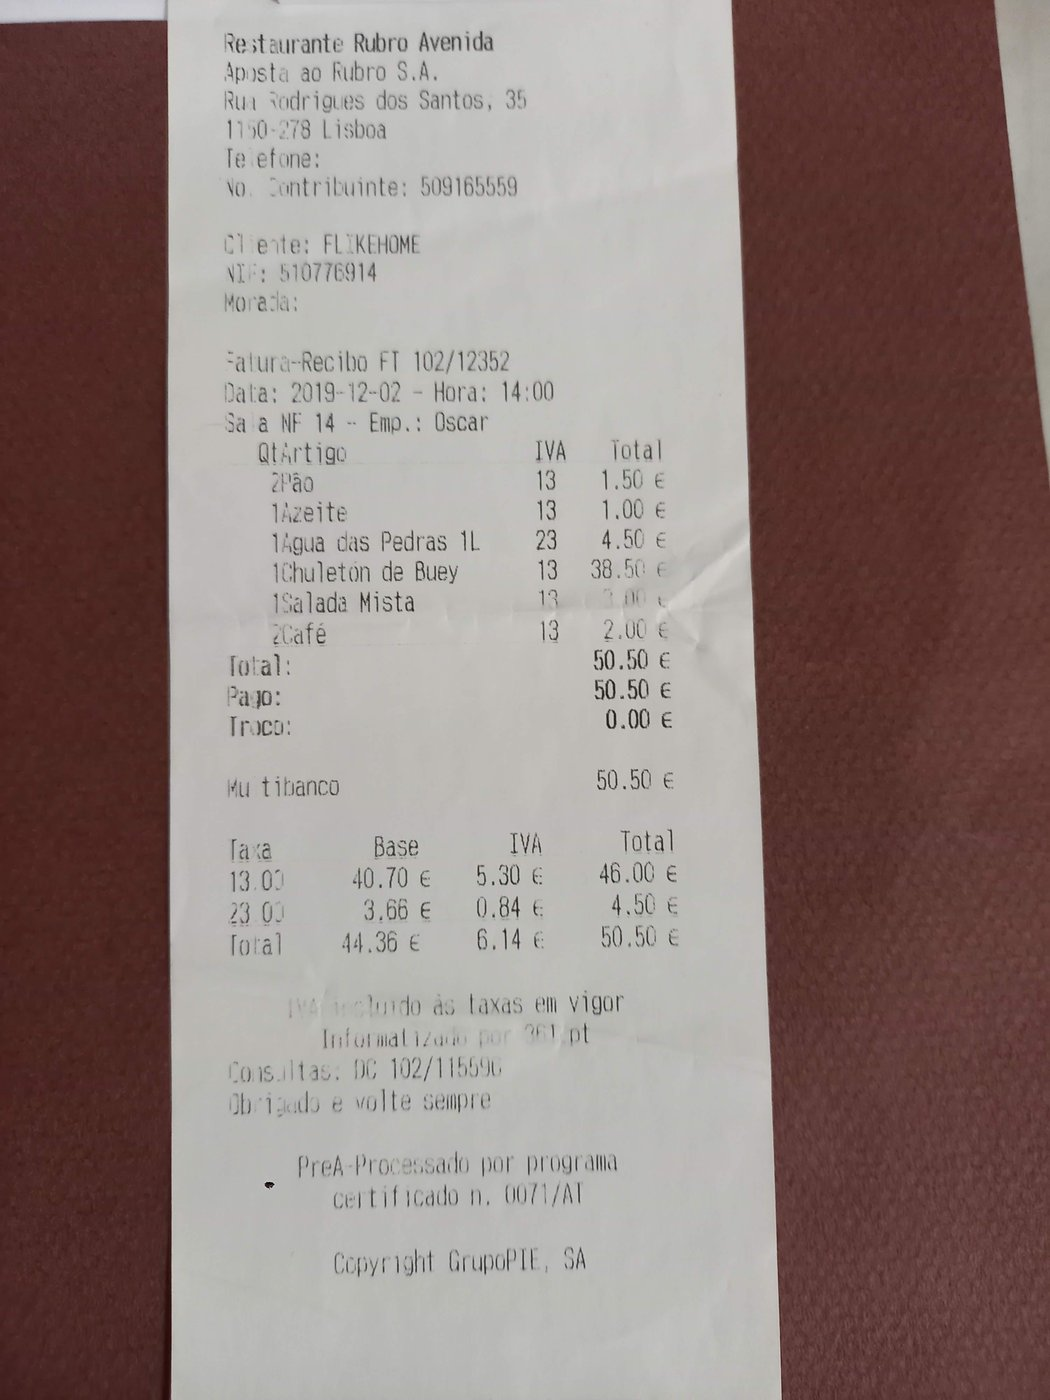

In [4]:
Image(filename=DOCUMENTS[-1], width=380)

### Os nós

O estado entra com o caminho da imagem e ganha uma chave por passo. Nenhum passo apaga o que o anterior escreveu, e é isso que permite auditar de onde veio cada campo.

In [5]:
class DocumentState(TypedDict):
    path: str
    text: str
    record: dict
    issues: list[str]

O OCR vai no próprio modelo multimodal, com a imagem em base64 como bloco de conteúdo. A alternativa descartada foi pedir os campos direto da imagem, em uma chamada só: funciona, mas joga fora a transcrição, e sem ela não dá para saber se um campo errado veio de leitura ruim ou de interpretação ruim.

In [6]:
def transcribe(state: DocumentState) -> dict:
    """Lê a imagem com o modelo multimodal e devolve o texto corrido."""
    data = base64.b64encode(Path(state["path"]).read_bytes()).decode()
    message = {
        "role": "user",
        "content": [
            {"type": "text", "text": "Transcreva todo o texto deste documento, linha por linha. Não corrija e não comente."},
            {"type": "image", "base64": data, "mime_type": "image/jpeg"},
        ],
    }
    return {"text": model.invoke([message]).content.strip()}

In [7]:
transcription = transcribe({"path": str(DOCUMENTS[-1])})

print(transcription["text"][:600])

Restaurante Rubro Avenida
Aposta ao Rubro S.A.
Rua Rodrigues dos Santos, 35
1150-278 Lisboa
Telefone:
No. Contribuinte: 509165559

Cliente: FLIKEHOME
NIF: 510776914
Morada:

Fatura-Recibo FT 102/12352
Data: 2019-12-02 - Hora: 14:00
Sala NF 14 - Emp.: Oscar
Qt.Artigo IVA Total
2Pão 13 1.50 €
1Azeite 13 1.00 €
1Água das Pedras 1L 23 4.50 €
1Chuleton de Buey 13 38.50 €
1Salada Mista 13 3.00 €
2Café 13 2.00 €
Total: 50.50 €
Pago: 50.50 €
Troco: 0.00 €

Multibanco 50.50 €

Taxa Base IVA Total
13.00 40.70 € 5.30 € 46.00 €
23.00 3.66 € 0.84 € 4.50 €
Total 44.36 € 6.14 € 50.50 €

IVA incluido às taxas


O esquema é o contrato da saída, e a `description` de cada campo é instrução. A lista de produtos é um esquema aninhado, porque a quantidade de linhas do talão só se conhece na hora.

In [8]:
class Product(BaseModel):
    name: str = Field(description="Nome do produto como aparece no documento")
    quantity: float = Field(description="Quantidade comprada")
    price: float = Field(description="Preço total da linha, em euros")


class Receipt(BaseModel):
    seller: str = Field(description="Nome comercial do estabelecimento, como na marca ou no logotipo, sem a razão social")
    date: str = Field(description="Data do documento no formato AAAA-MM-DD")
    products: list[Product] = Field(description="Uma entrada por linha de produto do documento")
    total: float = Field(description="Valor total pago, em euros")

In [9]:
def extract(state: DocumentState) -> dict:
    """Extrai os campos da transcrição no formato do esquema."""
    request = f"Extraia os campos do documento abaixo, sem inventar valor.\n\n{state['text']}"
    return {"record": model.with_structured_output(Receipt).invoke(request).model_dump()}

A conferência não chama o modelo: as regras são de domínio, custam zero token e nunca erram. O nó não corrige nada, só anota em `issues`, e o registro com problema segue marcado para a fila de revisão em vez de sumir.

In [10]:
def validate(state: DocumentState) -> dict:
    """Confere o registro pelas regras do domínio, sem chamar o modelo."""
    record = state["record"]
    issues = []
    try:
        date.fromisoformat(record["date"])
    except (TypeError, ValueError):
        issues.append("data fora do formato AAAA-MM-DD")
    if not record["products"]:
        issues.append("nenhum produto")
    items = sum(product["price"] for product in record["products"])
    if abs(items - record["total"]) > 0.01:
        issues.append(f"produtos somam {items:.2f} e o total é {record['total']:.2f}")
    return {"issues": issues}

### O grafo

Três nós em ordem, ligados por arestas fixas. O grafo trata um documento por invocação.

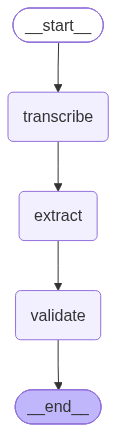

In [11]:
builder = StateGraph(DocumentState)

# nós
builder.add_node("transcribe", transcribe)
builder.add_node("extract", extract)
builder.add_node("validate", validate)

# arestas
builder.add_edge(START, "transcribe")
builder.add_edge("transcribe", "extract")
builder.add_edge("extract", "validate")
builder.add_edge("validate", END)

ingest = builder.compile()
Image(ingest.get_graph().draw_mermaid_png())

In [12]:
state = ingest.invoke({"path": str(DOCUMENTS[-1])})

print(state["issues"])
print(json.dumps(state["record"], ensure_ascii=False, indent=2))

[]
{
  "seller": "Restaurante Rubro Avenida",
  "date": "2019-12-02",
  "products": [
    {
      "name": "Pão",
      "quantity": 2.0,
      "price": 1.5
    },
    {
      "name": "Azeite",
      "quantity": 1.0,
      "price": 1.0
    },
    {
      "name": "Água das Pedras 1L",
      "quantity": 1.0,
      "price": 4.5
    },
    {
      "name": "Chuleton de Buey",
      "quantity": 1.0,
      "price": 38.5
    },
    {
      "name": "Salada Mista",
      "quantity": 1.0,
      "price": 3.0
    },
    {
      "name": "Café",
      "quantity": 2.0,
      "price": 2.0
    }
  ],
  "total": 50.5
}


### O lote

O grafo compilado é um runnable, então `batch` roda as vinte invocações com até cinco em paralelo, cada uma com o próprio estado. A ordem dos resultados é a ordem das entradas.

In [13]:
states = ingest.batch([{"path": str(path)} for path in DOCUMENTS], config={"max_concurrency": 5})

pd.DataFrame(
    [{"file": Path(s["path"]).name, "seller": s["record"]["seller"], "total": s["record"]["total"], "issues": s["issues"]} for s in states]
)

,file,seller,total,issues
0,20210213_140607.jpg,Moinho Velho,6.14,[]
1,20210215_162040.jpg,RESTAURANTE MANUEL JU,46.00,[]
2,20210215_162917.jpg,Moinho Velho,14.00,[]
3,20210215_163617.jpg,Farmacia Gaspar,8.80,[]
4,20210215_172611.jpg,"Pinço Doce - Distribuição Alimentar, S.A.",22.04,[produtos somam 21.94 e o total é 22.04]
5,20210217_033550.jpg,Farmacia Gaspar,34.10,[]
6,20210316_211314.jpg,RESTAURANTE MANUEL JULIO,19.50,[]
7,20210318_111820.jpg,JMTD FERRAGENS DO COMBROIDA,32.00,[]
8,20210318_201639.jpg,"Dia Portugal * Sur. Soc. Unip., Lda",6.25,[]
9,20210318_204623.jpg,IKEA ALFRAGIDE,69.99,[]


### O banco

O registro tem uma lista aninhada, e uma tabela relacional não guarda lista em coluna. O documento vira uma linha em `invoices`, cada produto vira uma linha em `products`, e o nome do arquivo liga as duas tabelas. As `issues` seguem junto, para a fila de revisão continuar consultável.

In [14]:
invoices = pd.DataFrame([
    {"file": Path(s["path"]).name, "seller": s["record"]["seller"], "date": s["record"]["date"],
     "total": s["record"]["total"], "issues": "; ".join(s["issues"])}
    for s in states
])
products = pd.DataFrame([
    {"file": Path(s["path"]).name, **product} for s in states for product in s["record"]["products"]
])
products.head()

,file,name,quantity,price
0,20210213_140607.jpg,Sopa de Carne /Peixe,1.00,2.90
1,20210213_140607.jpg,Miniaturas 18/KG.,0.18,3.24
2,20210215_162040.jpg,BROA UNIDADE,1.00,1.00
3,20210215_162040.jpg,LAMPREIA INTEIRA 1/2,1.00,40.00
4,20210215_162040.jpg,LEITE CREME,2.00,5.00


In [15]:
with sqlite3.connect("invoices.db") as connection:
    invoices.to_sql("invoices", connection, if_exists="replace", index=False)
    products.to_sql("products", connection, if_exists="replace", index=False)

print(len(invoices), "notas e", len(products), "produtos em invoices.db")

20 notas e 52 produtos em invoices.db


A consulta abaixo lê o banco com SQL puro e agrupa as notas por estabelecimento. É esse banco que um agente com uma ferramenta de SQL consegue consultar.

In [16]:
with sqlite3.connect("invoices.db") as connection:
    summary = pd.read_sql(
        "SELECT seller, COUNT(*) AS invoices, SUM(total) AS spent FROM invoices GROUP BY seller ORDER BY spent DESC",
        connection,
    )
summary

,seller,invoices,spent
0,INTERMARCHE LAGOA PO PARTIDO CARVOEIRO,1,224.20
1,"GALPESTE, S.A.",1,78.70
2,IKEA Alfragide,1,74.99
3,IKEA ALFRAGIDE,1,69.99
4,Restaurante Rubro Avenida,1,50.50
5,RESTAURANTE MANUEL JU,1,46.00
6,Farmacia Gaspar,2,42.90
7,JMTD FERRAGENS DO COMBROIDA,1,32.00
8,Pingo Doce,2,30.78
9,"Pinço Doce - Distribuição Alimentar, S.A.",1,22.04
